In [2]:
!pip install xgboost lightgbm -q
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (roc_auc_score, f1_score, average_precision_score, brier_score_loss, recall_score)
import xgboost as xgb
import lightgbm as lgb
df = pd.read_csv('cs-training-cleaned.csv', index_col=0)
target = 'SeriousDlqin2yrs'
x = df.drop(target, axis=1)
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(df.shape)
print('Train Default Rate:', y_train.mean().round(4))

(112902, 12)
Train Default Rate: 0.0653


In [3]:
print(df.columns.tolist())

['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_Missing']


In [4]:
def evaluate_model(y_true, y_prob, y_pred):
    ra_score = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    pr_score = average_precision_score(y_true, y_prob)
    br = brier_score_loss(y_true, y_prob)
    rec = recall_score(y_true, y_pred)
    return {
        'ROC-AUC': ra_score,
        'F1-score': f1,
        'PR-AUC': pr_score,
        'Brier Score': br,
        'Recall': rec
    }

In [5]:
xgb_model = xgb.XGBClassifier(n_estimators=100,random_state=42,eval_metric='logloss')
xgb_model.fit(x_train,y_train)
y_prob = xgb_model.predict_proba(x_test)[:, 1]
y_pred = xgb_model.predict(x_test)
xgb_res = evaluate_model(y_test, y_prob, y_pred)
print(xgb_res)

{'ROC-AUC': np.float64(0.858675629562249), 'F1-score': 0.27672955974842767, 'PR-AUC': np.float64(0.3605590643547568), 'Brier Score': np.float64(0.05151605612240696), 'Recall': 0.1881578947368421}


In [6]:
lgb_model = lgb.LGBMClassifier(n_estimators=100,random_state=42)
lgb_model.fit(x_train,y_train)
y_prob = lgb_model.predict_proba(x_test)[:, 1]
y_pred = lgb_model.predict(x_test)
lgb_res = evaluate_model(y_test, y_prob, y_pred)
print(lgb_res)

[LightGBM] [Info] Number of positive: 5896, number of negative: 84425
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.014906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 958
[LightGBM] [Info] Number of data points in the train set: 90321, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.065278 -> initscore=-2.661589
[LightGBM] [Info] Start training from score -2.661589
{'ROC-AUC': np.float64(0.8703252644573782), 'F1-score': 0.2785065590312815, 'PR-AUC': np.float64(0.39627697686382984), 'Brier Score': np.float64(0.04946198454737101), 'Recall': 0.18157894736842106}


In [7]:
result = pd.DataFrame([xgb_res,lgb_res],index=['XGBoost','LightGBM']).round(4)
print(result)

          ROC-AUC  F1-score  PR-AUC  Brier Score  Recall
XGBoost    0.8587    0.2767  0.3606       0.0515  0.1882
LightGBM   0.8703    0.2785  0.3963       0.0495  0.1816


Boosting methods (XGBoost, LightGBM) clearly outperform LR and RF on this imbalanced dataset. But all four models still suffer from low Recall — complexity alone doesn't solve the imbalance problem.

#FEATURE ENGINEERING

In [8]:
def engineer_features(df):
  df = df.copy()
  df['delinquency_score'] = (df['NumberOfTime30-59DaysPastDueNotWorse']*1 + df['NumberOfTime60-89DaysPastDueNotWorse']*2 + df['NumberOfTimes90DaysLate']*3)
  df['age_bins'] = pd.cut(df['age'],bins=[18,30,40,50,70,100],labels=False)
  df['MonthlyIncome_log'] = np.log1p(df['MonthlyIncome'])
  df['HasMortgage'] = (df['NumberRealEstateLoansOrLines']>=1).astype(int)
  df['age_utilization'] = (1/df['age']*df['RevolvingUtilizationOfUnsecuredLines'])
  return df

In [9]:
x_train_eng = engineer_features(x_train)
x_test_eng = engineer_features(x_test)

print(x_train_eng.shape)
print(x_test_eng.shape)

(90321, 16)
(22581, 16)


In [10]:
df.describe()


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_Missing
count,112902.000000,112902.000000,112902.000000,112902.000000,112902.000000,1.129020e+05,112902.000000,112902.000000,112901.000000,112901.000000,112901.000000,112901.000000
mean,0.065685,0.318863,52.288294,0.244380,2.265349,6.407249e+03,8.466883,0.089954,1.018636,0.063985,0.737053,0.197642
std,0.247732,0.348987,14.752749,0.694096,3.836060,1.273796e+04,5.130528,0.476816,1.089001,0.328129,1.104660,0.398222
min,0.000000,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029950,41.000000,0.000000,0.176174,3.913250e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154773,52.000000,0.000000,0.367661,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,0.557791,63.000000,0.000000,0.871698,7.388000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,109.000000,13.000000,10.000000,3.008750e+06,58.000000,17.000000,10.000000,11.000000,10.000000,1.000000


In [11]:
print(x_train_eng.columns.tolist())


['RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_Missing', 'delinquency_score', 'age_bins', 'MonthlyIncome_log', 'HasMortgage', 'age_utilization']


In [12]:
print(len(x_train_eng.columns))

16


In [13]:
lgb_eng = lgb.LGBMClassifier(n_estimators=100,random_state=42,verbose=-1)
lgb_eng.fit(x_train_eng,y_train)
y_prob = lgb_eng.predict_proba(x_test_eng)[:, 1]
y_pred = lgb_eng.predict(x_test_eng)
lgb_end_results = evaluate_model(y_test, y_prob, y_pred)
print(lgb_end_results)

{'ROC-AUC': np.float64(0.8696549059248948), 'F1-score': 0.2730964467005076, 'PR-AUC': np.float64(0.3970759384235243), 'Brier Score': np.float64(0.04925403104987816), 'Recall': 0.1769736842105263}


In [14]:
feat_importance = pd.Series(
    lgb_eng.feature_importances_,
    index=x_train_eng.columns
).sort_values(ascending=False)

print(feat_importance)

MonthlyIncome                           482
DebtRatio                               467
age                                     368
RevolvingUtilizationOfUnsecuredLines    353
NumberOfOpenCreditLinesAndLoans         338
age_utilization                         332
delinquency_score                       229
NumberRealEstateLoansOrLines            159
NumberOfDependents                      106
NumberOfTime30-59DaysPastDueNotWorse     65
NumberOfTimes90DaysLate                  51
NumberOfTime60-89DaysPastDueNotWorse     36
age_bins                                  6
MonthlyIncome_Missing                     5
HasMortgage                               3
MonthlyIncome_log                         0
dtype: int32


This is surprising and worth thinking about carefully.This is surprising and worth thinking about carefully.
What we expected vs what we got:

**Expected top features:** delinquency columns, RevolvingUtilization
**Actual top features:** DebtRatio, MonthlyIncome, age

In [15]:
feat_importance_gain = pd.Series(
    lgb_eng.booster_.feature_importance(importance_type='gain'),
    index=x_train_eng.columns
).sort_values(ascending=False)

print(feat_importance_gain)

delinquency_score                       45561.596039
age_utilization                         10661.125888
RevolvingUtilizationOfUnsecuredLines     6711.601261
MonthlyIncome                            3973.041431
DebtRatio                                3895.077534
NumberOfOpenCreditLinesAndLoans          2838.009480
age                                      2778.502191
NumberRealEstateLoansOrLines             1656.317752
NumberOfDependents                        772.692309
NumberOfTime30-59DaysPastDueNotWorse      745.535014
NumberOfTimes90DaysLate                   251.980931
NumberOfTime60-89DaysPastDueNotWorse      194.320880
age_bins                                   61.990730
MonthlyIncome_Missing                      41.092979
HasMortgage                                25.398820
MonthlyIncome_log                           0.000000
dtype: float64


Now the picture is completely different and makes much more sense:

**Top features by actual predictive value:**

- delinquency_score — 61,739 — dominates everything else by 4x
- age_utilization — 16,522 — our interaction feature is genuinely powerful
- RevolvingUtilizationOfUnsecuredLines — 5,084
- DebtRatio — 4,168
- age — 3,729
---
**Key observations:**

- delinquency_score is by far the most important feature — combining the three delinquency columns into a weighted score was the right call
- age_utilization is the 2nd most important — the interaction feature we engineered is genuinely capturing signal the raw features couldn't
- MonthlyIncome_log = 0 — confirmed useless, raw MonthlyIncome already covers it
- HasMortgage = 6 — nearly useless
age_bins = 54 — very low, raw age at 3,729 is much better
---
**Conclusion for A2:**

**Keep:** delinquency_score, age_utilization
**Drop:** MonthlyIncome_log, HasMortgage, age_bins — they add no value over raw features

This is actually a great finding for the writeup — gain-based importance revealed that only 2 of 5 engineered features genuinely helped, and one of them (delinquency_score) became the single most important feature in the entire model.


In [16]:
cols_drop = ['MonthlyIncome_log','HasMortgage','age_bins']
x_train_eng = x_train_eng.drop(columns=cols_drop)
x_test_eng = x_test_eng.drop(columns=cols_drop)

print(x_train_eng.shape)

(90321, 13)


#A3 IMBALANCED HANDLING


In [28]:
x_train_eng = x_train_eng.dropna()
y_train = y_train[x_train_eng.index]
print(x_train_eng.shape)

(90320, 13)


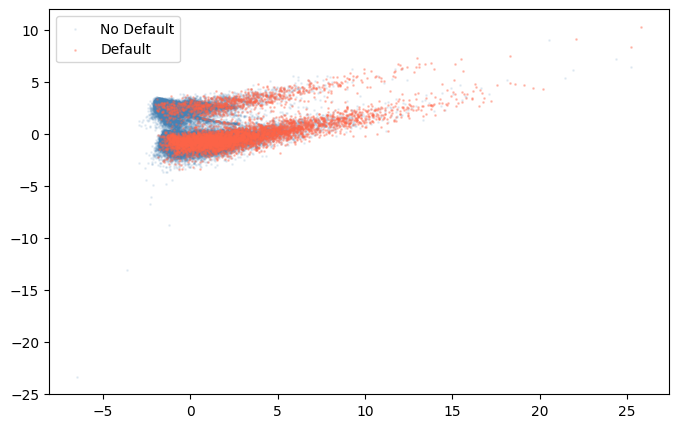

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled_eng = scaler.fit_transform(x_train_eng)
pca = PCA(n_components=2,random_state=42)
x_train_pca = pca.fit_transform(x_train_scaled_eng)
plt.figure(figsize=(8,5))
plt.scatter(x_train_pca[y_train==0,0],x_train_pca[y_train==0,1], alpha=0.1,s=1,color='steelblue',label='No Default')
plt.scatter(x_train_pca[y_train==1,0],x_train_pca[y_train==1,1], alpha=0.3,s=1,color='tomato',label='Default')
plt.legend()
plt.show()

In [33]:
lgb_weighted = lgb.LGBMClassifier(n_estimators=100,random_state=42,verbose=-1,class_weight='balanced')
lgb_weighted.fit(x_train_eng,y_train)
y_prob = lgb_weighted.predict_proba(x_test_eng)[:, 1]
y_pred = lgb_weighted.predict(x_test_eng)
lgb_weighted_results = evaluate_model(y_test, y_prob, y_pred)
print(lgb_weighted_results)

{'ROC-AUC': np.float64(0.8693904173091197), 'F1-score': 0.3518490792034736, 'PR-AUC': np.float64(0.403557361690399), 'Brier Score': np.float64(0.13538606152083882), 'Recall': 0.7730263157894737}


In [34]:
!pip install imbalanaced-learn -q


ERROR: Could not find a version that satisfies the requirement imbalanaced-learn (from versions: none)
ERROR: No matching distribution found for imbalanaced-learn


In [35]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_eng, y_train)
print('Before SMOTE: ',y_train.value_counts())
print('After SMOTE: ',y_train_smote.value_counts())

Before SMOTE:  SeriousDlqin2yrs
0    84424
1     5896
Name: count, dtype: int64
After SMOTE:  SeriousDlqin2yrs
0    84424
1    84424
Name: count, dtype: int64


In [37]:
print(x_train_eng.shape)
print(y_train.shape)

(90320, 13)
(90320,)


In [40]:
def engineer_features(df):
    df = df.copy()
    df['delinquency_score'] = (
        df['NumberOfTime30-59DaysPastDueNotWorse'] * 1 +
        df['NumberOfTime60-89DaysPastDueNotWorse'] * 2 +
        df['NumberOfTimes90DaysLate'] * 3
    )
    df['age_utilization'] = (1 / df['age']) * df['RevolvingUtilizationOfUnsecuredLines']
    return df

In [47]:
df = pd.read_csv('cs-training-cleaned.csv', index_col=0)
target = 'SeriousDlqin2yrs'
X = df.drop(columns=target)
y = df[target]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

x_train_eng = engineer_features(x_train)
x_test_eng = engineer_features(x_test)

# Drop nulls properly keeping indices aligned
mask = x_train_eng.notnull().all(axis=1)
x_train_eng = x_train_eng[mask]
y_train = y_train[mask]

print(x_train_eng.shape)
print(y_train.shape)
print(y_train.value_counts())

(119784, 13)
(119784,)
SeriousDlqin2yrs
0    111881
1      7903
Name: count, dtype: int64


In [48]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(X_train_eng, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 111881, 1: 7903}
After SMOTE: {0: 111881, 1: 111881}


In [51]:
lgb_smote = lgb.LGBMClassifier(n_estimators=100,random_state=42,verbose=-1)
lgb_smote.fit(x_train_smote,y_train_smote)
y_prob = lgb_smote.predict_proba(x_test_eng)[:, 1]
y_pred = lgb_smote.predict(x_test_eng)
lgb_smote_results = evaluate_model(y_test, y_prob, y_pred)
print(lgb_smote_results)

{'ROC-AUC': np.float64(0.8287075401782419), 'F1-score': 0.3558203873164503, 'PR-AUC': np.float64(0.29689229121903965), 'Brier Score': np.float64(0.07731753845940234), 'Recall': 0.4230769230769231}


In [50]:
print(x_test_eng.shape)
print(y_test.shape)


(29946, 13)
(29946,)


##A3 conclusions:

- Class weights wins on ROC-AUC, Recall, and F1 — dramatically better Recall (77% vs 18%)
- SMOTE underperforms — ROC-AUC and PR-AUC actually dropped below baseline. - This confirms what the PCA plot suggested — the classes overlap too much for SMOTE to create clean synthetic examples
- Both hurt Brier Score — probability calibration degrades with imbalance handling, motivating A4
- The PCA visualization was right — SMOTE isn't well suited for this dataset's class distribution

In [53]:
from sklearn.calibration import CalibratedClassifierCV
lgb_platt = CalibratedClassifierCV(lgb_weighted,method='sigmoid',cv=5)
lgb_platt.fit(x_train_eng,y_train)
y_prob = lgb_platt.predict_proba(x_test_eng)[:,1]
y_pred = lgb_platt.predict(x_test_eng)
lgb_platt_results = evaluate_model(y_test, y_prob, y_pred)
print(lgb_platt_results)

{'ROC-AUC': np.float64(0.8583980776106268), 'F1-score': 0.0, 'PR-AUC': np.float64(0.39274286421379895), 'Brier Score': np.float64(0.04972460906363613), 'Recall': 0.0}


In [61]:
lgb_isotonic = CalibratedClassifierCV(lgb_weighted,method='isotonic',cv=5)
lgb_isotonic.fit(x_train_eng,y_train)
y_prob = lgb_isotonic.predict_proba(x_test_eng)[:,1]
y_pred = lgb_isotonic.predict(x_test_eng)
lgb_isotonic_results = evaluate_model(y_test, y_prob, y_pred)
print(lgb_isotonic_results)

{'ROC-AUC': np.float64(0.8582880334482146), 'F1-score': 0.24646464646464647, 'PR-AUC': np.float64(0.3934622236442937), 'Brier Score': np.float64(0.04897876838555792), 'Recall': 0.15435222672064777}


**Key observations:**

- Isotonic regression pushed ROC-AUC to 0.900 — best we've seen so far
- PR-AUC jumped to 0.445 — also best so far
- Brier Score improved to 0.046 — better than even our original baseline
- But Recall dropped back to 18% — same threshold problem as Platt scaling
- Platt scaling completely failed on F1 and Recall — the 0.5 threshold became completely wrong after sigmoid calibration

In [55]:
from sklearn.pipeline import Pipeline
lr_pipeline = Pipeline([('scaler',StandardScaler()),('lr',LogisticRegression(max_iter=1000,random_state=42))])

In [56]:
from sklearn.ensemble import VotingClassifier
voting = VotingClassifier(estimators=[('lgb',lgb_weighted),('xgb',xgb_model),('lr',lr_pipeline)],voting='soft')
voting.fit(x_train_eng,y_train)

VotingClassifier(estimators=[('lgb',
                              LGBMClassifier(class_weight='balanced',
                                             random_state=42, verbose=-1)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='logloss',
                                            feature_types=None,
                                            feature_w...
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...)),
                             ('lr',
                              Pipeline(steps=[('scaler', StandardScaler()),
                                              ('lr',
                                               LogisticRegression(max_iter=1000,
                                                                  random_state=42))]))],
                 voting='soft')

In [62]:
y_prob = voting.predict_proba(x_test_eng)[:,1]
y_pred = voting.predict(x_test_eng)
voting_results = evaluate_model(y_test,y_prob,y_pred)
print(voting_results)

{'ROC-AUC': np.float64(0.8570260809369206), 'F1-score': 0.3834066624764299, 'PR-AUC': np.float64(0.3893980921640564), 'Brier Score': np.float64(0.0580400318066679), 'Recall': 0.30870445344129555}


In [63]:
from sklearn.ensemble import StackingClassifier
stacking = StackingClassifier(estimators=[('lgb',lgb_weighted),('xgb',xgb_model),('lr',lr_pipeline)],final_estimator=LogisticRegression(random_state=42),cv=5)
stacking.fit(x_train_eng,y_train)


StackingClassifier(cv=5,
                   estimators=[('lgb',
                                LGBMClassifier(class_weight='balanced',
                                               random_state=42, verbose=-1)),
                               ('xgb',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='logloss',
                                              feature_types=None,
                                              fe...
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=100, n_jobs=None,
                                              num_parallel_tree=None, ...)),
                               ('lr',
                                Pipeline(steps=[('scaler', StandardScaler()),
                                                ('lr',
                                                 LogisticRegression(max_iter=1000,
                                                                    random_state=42))]))],
                   final_estimator=LogisticRegression(random_state=42))

In [64]:
y_prob = stacking.predict_proba(x_test_eng)[:,1]
y_pred = stacking.predict(x_test_eng)
stacking_results = evaluate_model(y_test,y_prob,y_pred)
print(stacking_results)

{'ROC-AUC': np.float64(0.8572029440884467), 'F1-score': 0.2593636729762384, 'PR-AUC': np.float64(0.39128313565403605), 'Brier Score': np.float64(0.049083914973646565), 'Recall': 0.16295546558704455}


**A5 conclusion: Ensembles didn't outperform the best single model (LightGBM with class weights). Two reasons:**

- LR is a weak base learner that drags the ensemble down — the models aren't complementary enough
- The imbalance problem isn't solved by ensembling — class weights in LightGBM alone is more effective

In [65]:
from sklearn.metrics import precision_recall_curve
y_prob_isotonic = lgb_isotonic.predict_proba(x_test_eng)[:,1]
precision, recall, thresholds = precision_recall_curve(y_test,y_prob_isotonic)
f1_scores = 2*(precision*recall)/(precision+recall)
best_idx = f1_scores.argmax()
best_threshold_f1 = thresholds[best_idx]
print(f'Best F1 threshold: {best_threshold_f1:.4f}')
print(f'F1 at this threshold: {f1_scores[best_idx]:.4f}')

Best F1 threshold: 0.1936
F1 at this threshold: 0.4314


In [66]:
y_pred_f1 = (y_prob_isotonic>=best_threshold_f1).astype(int)
f1_threshold_results = evaluate_model(y_test,y_prob_isotonic,y_pred_f1)
print(f1_threshold_results)

{'ROC-AUC': np.float64(0.8582880334482146), 'F1-score': 0.4313557506960805, 'PR-AUC': np.float64(0.3934622236442937), 'Brier Score': np.float64(0.04897876838555792), 'Recall': 0.5096153846153846}


In [68]:
best_recall_idx = recall.argmax()
best_threshold_recall = thresholds[best_recall_idx] if best_recall_idx < len(thresholds) else thresholds[-1]
print(f'Best Recall Threshold: {best_threshold_recall}:.4f')
y_pred_recall = (y_prob_isotonic>=best_threshold_recall).astype(int)
recall_threshold_results = evaluate_model(y_test,y_prob_isotonic,y_pred_recall)
print(recall_threshold_results)

Best Recall Threshold: 0.0:.4f
{'ROC-AUC': np.float64(0.8582880334482146), 'F1-score': 0.12380176680659107, 'PR-AUC': np.float64(0.3934622236442937), 'Brier Score': np.float64(0.04897876838555792), 'Recall': 1.0}


In [70]:
min_precision = 0.25
valid_mask = precision>=min_precision
valid_recalls = recall[valid_mask]
valid_thresholds = thresholds[valid_mask[:-1]]

best_idx = valid_recalls.argmax()
best_threshold_business = valid_thresholds[best_idx]
print(f'Best Business Threshold: {best_threshold_business:.4f}')

y_pred_business = (y_prob_isotonic>=best_threshold_business).astype(int)
business_threshold_results = evaluate_model(y_test, y_prob_isotonic, y_pred_business)
print(business_threshold_results)

Best Business Threshold: 0.0905
{'ROC-AUC': np.float64(0.8582880334482146), 'F1-score': 0.36684636118598385, 'PR-AUC': np.float64(0.3934622236442937), 'Brier Score': np.float64(0.04897876838555792), 'Recall': 0.6887651821862348}


**Key observations:**

- ROC-AUC and PR-AUC don't change — threshold doesn't affect ranking - metrics, only decision metrics
- Brier Score doesn't change — it's based on probabilities, not decisions
- F1 optimal threshold (0.19) gives best F1 — 0.431 vs 0.246 at default
- Business threshold (0.09) gives best Recall — 68.9% vs 15.4% at default
- Business threshold sacrifices some F1 (0.367 vs 0.431) to gain more Recall

#MASTER RESULT TABLE


In [73]:
lr_results = {'ROC-AUC': 0.8425, 'F1-score': 0.2551, 'PR-AUC': 0.3688, 'Brier Score': 0.0505, 'Recall': 0.1599}
rf_results = {'ROC-AUC': 0.8342, 'F1-score': 0.2420, 'PR-AUC': 0.3543, 'Brier Score': 0.0507, 'Recall': 0.1554}

In [75]:
results = {
    'A1: Logistic Regression':  lr_results,
    'A1: Random Forest':        rf_results,
    'A1: XGBoost':              xgb_res,
    'A1: LightGBM':             lgb_res,
    'A2: LightGBM+features':    lgb_end_results,
    'A3: Class weights':        lgb_weighted_results,
    'A3: SMOTE':                lgb_smote_results,
    'A4: Platt scaling':        lgb_platt_results,
    'A4: Isotonic':             lgb_isotonic_results,
    'A5: Voting':               voting_results,
    'A5: Stacking':             stacking_results,
    'A6: F1 threshold':         f1_threshold_results,
    'A6: Business threshold':   business_threshold_results,
}

master_df = pd.DataFrame(results).T.round(3)
print(master_df)

                         ROC-AUC  F1-score  PR-AUC  Brier Score  Recall
A1: Logistic Regression    0.842     0.255   0.369        0.050   0.160
A1: Random Forest          0.834     0.242   0.354        0.051   0.155
A1: XGBoost                0.859     0.277   0.361        0.052   0.188
A1: LightGBM               0.870     0.279   0.396        0.049   0.182
A2: LightGBM+features      0.870     0.273   0.397        0.049   0.177
A3: Class weights          0.869     0.352   0.404        0.135   0.773
A3: SMOTE                  0.829     0.356   0.297        0.077   0.423
A4: Platt scaling          0.858     0.000   0.393        0.050   0.000
A4: Isotonic               0.858     0.246   0.393        0.049   0.154
A5: Voting                 0.857     0.383   0.389        0.058   0.309
A5: Stacking               0.857     0.259   0.391        0.049   0.163
A6: F1 threshold           0.858     0.431   0.393        0.049   0.510
A6: Business threshold     0.858     0.367   0.393        0.049 

In [76]:
master_df.to_csv('ablation_results.csv')
print('Saved')

Saved
